In [10]:
import copy
import math
from typing import List, Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt



In [11]:

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


In [12]:


def state_dict_to_list(sd: dict) -> List[np.ndarray]:
    return [v.detach().cpu().numpy() for _, v in sd.items()]

def list_to_state_dict(model: nn.Module, lst: List[np.ndarray]) -> dict:
    sd = model.state_dict()
    keys = list(sd.keys())
    new = {}
    for k, arr in zip(keys, lst):
        new[k] = torch.tensor(arr, dtype=sd[k].dtype)
    return new

def load_list_into(model: nn.Module, lst: List[np.ndarray]):
    sd_new = list_to_state_dict(model, lst)
    model.load_state_dict(sd_new, strict=True)


In [13]:
def avg_aggregate(updates: List[Tuple[List[np.ndarray], int]]) -> Tuple[List[np.ndarray], int]:
    if len(updates) == 0: return [], 0
    weights = np.array([u[1] for u in updates], dtype=np.float64)
    if weights.sum() == 0: weights = np.ones_like(weights)
    w = weights / weights.sum()
    arrays_per_param = list(zip(*[u[0] for u in updates]))
    agg = []
    for param_vals in arrays_per_param:
        stacked = np.stack(param_vals, axis=0)
        agg_param = (w.reshape((-1,) + (1,) * (stacked.ndim - 1)) * stacked).sum(axis=0)
        agg.append(agg_param)
    total = int(weights.sum())
    return agg, total


In [14]:
class Client:
    def __init__(self, cid: int, dataset: Subset, device='cpu'):
        self.cid = cid
        self.dataset = dataset
        self.device = device

    def local_train(self, model: nn.Module, epochs=1, batch_size=32, lr=0.01):
        loader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)
        local_model = copy.deepcopy(model).to(self.device)
        opt = optim.SGD(local_model.parameters(), lr=lr, momentum=0.9)
        loss_fn = nn.CrossEntropyLoss()
        local_model.train()
        for _ in range(epochs):
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                opt.zero_grad()
                loss_fn(local_model(X), y).backward()
                opt.step()
        return state_dict_to_list(local_model.state_dict()), len(loader.dataset)


In [15]:
class EdgeServer:
    def __init__(self, eid: int, clients: List[Client]):
        self.eid = eid
        self.clients = clients

    def aggregate(self, global_model: nn.Module, client_epochs=1, client_batch=32, client_lr=0.01):
        updates = []
        for client in self.clients:
            state_list, num_ex = client.local_train(global_model, epochs=client_epochs,
                                                    batch_size=client_batch, lr=client_lr)
            updates.append((state_list, num_ex))
        edge_state, total = avg_aggregate(updates)
        return edge_state, total


In [16]:
class MasterServer:
    def __init__(self, model: nn.Module, edge_servers: List[EdgeServer], device='cpu'):
        self.model = model
        self.edge_servers = edge_servers
        self.device = device

    def run_round(self, client_epochs=1, client_batch=32, client_lr=0.01):
        edge_updates = []
        for edge in self.edge_servers:
            edge_state, edge_examples = edge.aggregate(self.model, client_epochs, client_batch, client_lr)
            edge_updates.append((edge_state, edge_examples))
        agg_state, _ = avg_aggregate(edge_updates)
        load_list_into(self.model, agg_state)

    def evaluate(self, test_loader: DataLoader):
        self.model.eval()
        correct = 0
        total = 0
        loss_fn = nn.CrossEntropyLoss()
        loss_sum = 0.0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(self.device), y.to(self.device)
                logits = self.model(X)
                loss_sum += loss_fn(logits, y).item()
                preds = logits.argmax(dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)
        return loss_sum / len(test_loader), correct / total


In [17]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Split dataset among clients (even split)
num_clients = 12
num_edges = 3
client_len = len(train_dataset) // num_clients
client_subsets = [Subset(train_dataset, list(range(i * client_len, (i + 1) * client_len)))
                  for i in range(num_clients)]
clients = [Client(cid=i, dataset=client_subsets[i]) for i in range(num_clients)]

# Assign clients to edges
clients_per_edge = math.ceil(num_clients / num_edges)
edges = []
for e in range(num_edges):
    start = e * clients_per_edge
    end = min((e + 1) * clients_per_edge, num_clients)
    edges.append(EdgeServer(eid=e, clients=clients[start:end]))

# Master model
master_model = SimpleNet()
master = MasterServer(model=master_model, edge_servers=edges)


100%|██████████| 9.91M/9.91M [02:05<00:00, 79.2kB/s]
100%|██████████| 28.9k/28.9k [00:01<00:00, 19.1kB/s]
100%|██████████| 1.65M/1.65M [03:15<00:00, 8.43kB/s]
100%|██████████| 4.54k/4.54k [00:01<00:00, 3.80kB/s]


In [18]:
ROUNDS = 5
global_accuracies = []
losses = []

for r in range(1, ROUNDS + 1):
    print(f"--- Round {r} ---")
    master.run_round(client_epochs=1, client_batch=32, client_lr=0.05)
    loss, acc = master.evaluate(test_loader)
    print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc*100:.2f}%")
    global_accuracies.append(acc)
    losses.append(loss)


--- Round 1 ---
Test Loss: 0.2732, Test Accuracy: 91.89%
--- Round 2 ---
Test Loss: 0.1934, Test Accuracy: 94.31%
--- Round 3 ---
Test Loss: 0.1603, Test Accuracy: 95.06%
--- Round 4 ---
Test Loss: 0.1335, Test Accuracy: 95.74%
--- Round 5 ---
Test Loss: 0.1243, Test Accuracy: 96.23%


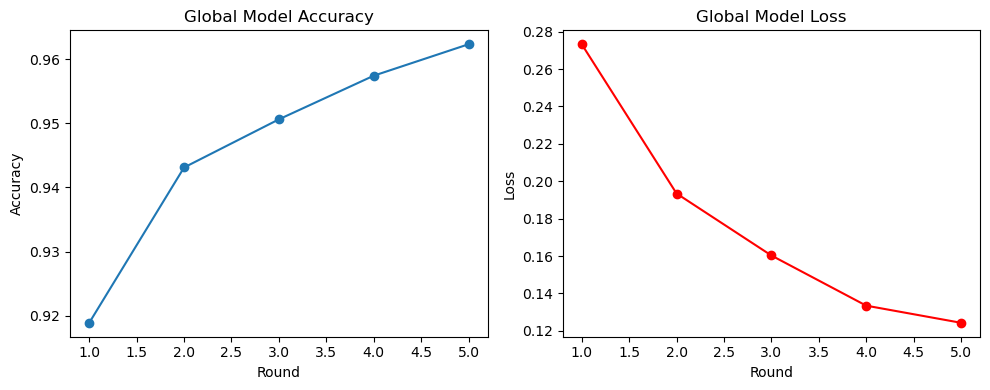

In [19]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, ROUNDS + 1), global_accuracies, marker='o')
plt.title("Global Model Accuracy")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.subplot(1, 2, 2)
plt.plot(range(1, ROUNDS + 1), losses, marker='o', color='r')
plt.title("Global Model Loss")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()
